# Capítulo 1 — La imagen como objeto matemático

## Objetivo del notebook

Entender qué es una imagen desde el punto de vista matemático y computacional. En este primer notebook se construye la base conceptual para todo el curso: una imagen se tratará como una función bidimensional, una matriz de intensidades y, más adelante, como una señal susceptible de transformaciones, convolución y análisis en Fourier.


## 1. Motivación

En visión computacional y óptica de Fourier, una imagen no se estudia solo como una fotografía visual, sino como un objeto matemático.

Eso significa que una imagen puede analizarse en términos de:

- dominio espacial
- intensidad
- estructuras locales
- frecuencia espacial
- transformaciones lineales
- degradación y reconstrucción

La idea central del capítulo es:

> **Una imagen digital puede modelarse como una función bidimensional discretizada.**


## 2. Imagen como función matemática

Una imagen en escala de grises puede representarse como:

$$
f(x,y)
$$

Donde:

- $x$ representa la posición horizontal
- $y$ representa la posición vertical
- $f(x,y)$ representa la intensidad luminosa en ese punto

En el mundo continuo, esto es una función definida sobre un plano.

En el mundo digital, la imagen se discretiza y se convierte en una matriz:

$$
I[m,n]
$$

Donde:

- $m$ y $n$ son índices enteros
- cada entrada de la matriz almacena un nivel de intensidad


## 3. Representación matricial

Una imagen en escala de grises de tamaño $M \times N$ puede escribirse como:

$$
I =
\begin{bmatrix}
I[0,0] & I[0,1] & \cdots & I[0,N-1] \\
I[1,0] & I[1,1] & \cdots & I[1,N-1] \\
\vdots & \vdots & \ddots & \vdots \\
I[M-1,0] & I[M-1,1] & \cdots & I[M-1,N-1]
\end{bmatrix}
$$

Cada elemento representa la intensidad de un píxel.

Ejemplo típico en imágenes de 8 bits:

- 0 = negro
- 255 = blanco
- valores intermedios = tonos de gris


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

## 4. Crear una imagen sencilla como matriz

Primero construiremos manualmente una imagen pequeña para ver con claridad qué significa que una imagen sea una matriz.

In [2]:
img = np.array([
    [0, 0, 0, 0, 0],
    [0, 255, 255, 255, 0],
    [0, 255, 100, 255, 0],
    [0, 255, 255, 255, 0],
    [0, 0, 0, 0, 0]
], dtype=np.uint8)

print(img)
print('Shape:', img.shape)
print('Tipo de dato:', img.dtype)


[[  0   0   0   0   0]
 [  0 255 255 255   0]
 [  0 255 100 255   0]
 [  0 255 255 255   0]
 [  0   0   0   0   0]]
Shape: (5, 5)
Tipo de dato: uint8


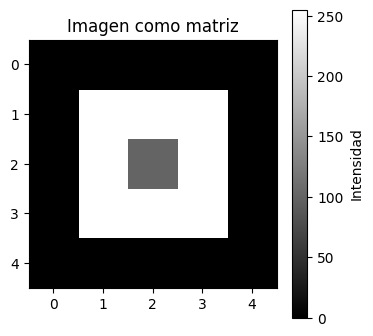

In [3]:
plt.figure(figsize=(4,4))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('Imagen como matriz')
plt.colorbar(label='Intensidad')
plt.show()


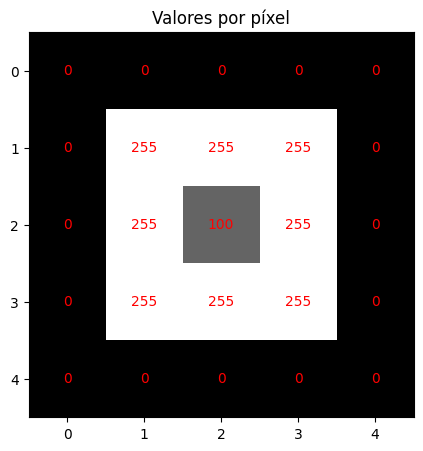

In [4]:
plt.figure(figsize=(5,5))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('Valores por píxel')

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        plt.text(j, i, str(img[i, j]), ha='center', va='center', color='red')

plt.show()


## 5. Tamaño, resolución y `shape`

La propiedad `shape` de una imagen indica su tamaño matricial.

Por ejemplo:

- `(5, 5)` significa 5 filas y 5 columnas
- `(512, 512)` significa una imagen cuadrada de 512×512 píxeles
- `(512, 512, 3)` corresponde típicamente a una imagen RGB


## 6. Cargar una imagen real

Ahora pasamos de una matriz construida a mano a una imagen real en escala de grises.

In [14]:
# def cargar_imagen_gris(ruta):
#     imagen = Image.open(ruta).convert('L')
#     return np.array(imagen)


def cargar_imagen_gris(ruta):
    img = plt.imread(ruta)

    # Si la imagen es RGB, convertir a gris
    if len(img.shape) == 3:
        img = np.mean(img, axis=2)

    return img

Cambia `'ruta'` por la ruta de una imagen que tengas en tu carpeta de trabajo.

In [27]:
# Ejemplo de uso

ruta = r'../data/'
img_real = cargar_imagen_gris( ruta + 'lenna.jpg')

print('Shape:', img_real.shape)
print('Tipo de dato:', img_real.dtype)
print('Valor mínimo:', img_real.min())
print('Valor máximo:', img_real.max())


Shape: (256, 256)
Tipo de dato: uint8
Valor mínimo: 0
Valor máximo: 255


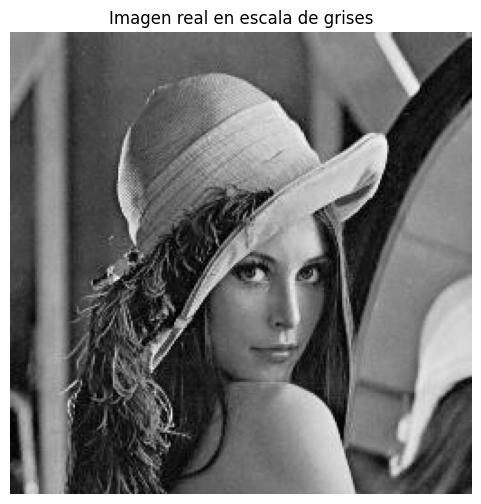

In [ ]:
# Visualización de la imagen real
plt.figure(figsize=(6,6))
plt.imshow(img_real, cmap='gray')
plt.title('Imagen real en escala de grises')
plt.axis('off')
plt.show()


## 7. Imagen como señal bidimensional

Una señal de una variable puede escribirse como $s(t)$.

Una imagen, en cambio, es una señal de dos variables:

$$
f(x,y)
$$

Aquí ya no estudiamos variación respecto al tiempo, sino respecto al espacio. Por eso aparecen conceptos como:

- frecuencia espacial
- bordes
- texturas
- orientación
- periodicidad bidimensional


## 8. Intensidad y perfiles

Una forma muy útil de estudiar una imagen es tomar una fila o una columna y analizarla como señal 1D.

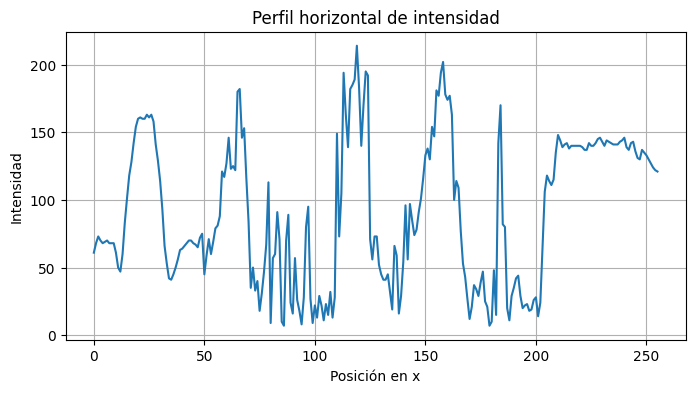

In [29]:
# Perfil horizontal de una imagen real
fila = img_real[img_real.shape[0] // 2, :]

plt.figure(figsize=(8,4))
plt.plot(fila)
plt.title('Perfil horizontal de intensidad')
plt.xlabel('Posición en x')
plt.ylabel('Intensidad')
plt.grid(True)
plt.show()


Idea clave: una imagen 2D puede analizarse localmente como muchas señales 1D. Esto será muy útil más adelante al estudiar convolución, detección de bordes y transformada de Fourier.

## 9. Operaciones básicas sobre imágenes

Si tratamos una imagen como matriz, podemos transformarla numéricamente.

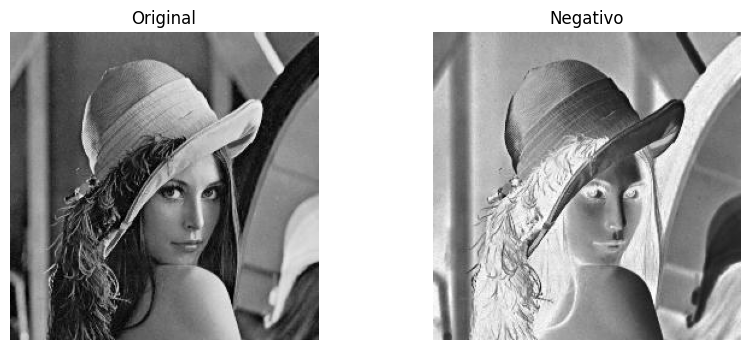

In [30]:
# Ejemplo con una imagen cargada
img_neg = 255 - img_real

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img_real, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_neg, cmap='gray')
plt.title('Negativo')
plt.axis('off')

plt.show()


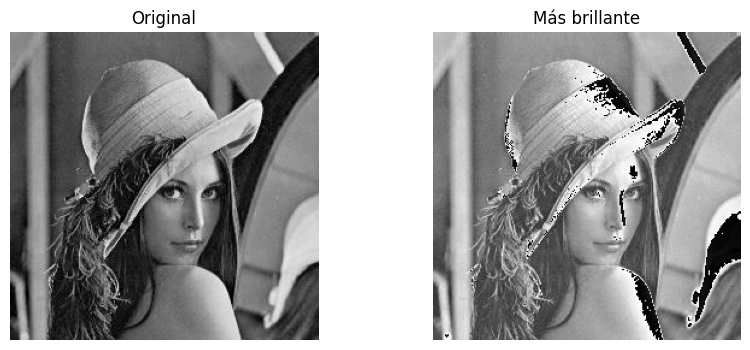

In [31]:
# Ajuste lineal de brillo
img_brillo = np.clip(img_real + 50, 0, 255)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img_real, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_brillo, cmap='gray')
plt.title('Más brillante')
plt.axis('off')

plt.show()


## 10. Histograma de intensidades

El histograma muestra cuántos píxeles hay en cada nivel de intensidad.

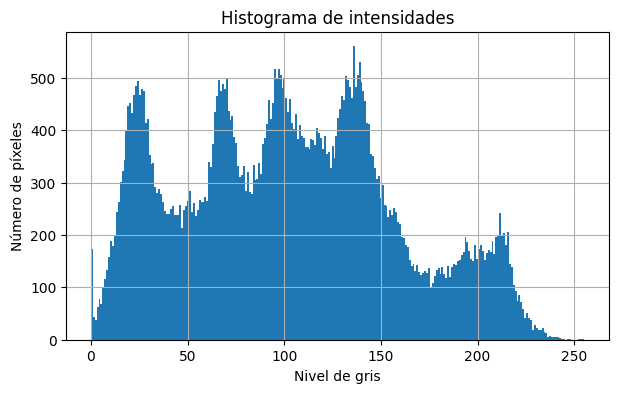

In [32]:
# Histograma de una imagen real
plt.figure(figsize=(7,4))
plt.hist(img_real.ravel(), bins=256)
plt.title('Histograma de intensidades')
plt.xlabel('Nivel de gris')
plt.ylabel('Número de píxeles')
plt.grid(True)
plt.show()


Interpretación rápida:

- histograma concentrado en valores bajos → imagen oscura
- histograma concentrado en valores altos → imagen clara
- histograma extendido → mayor rango dinámico


## 11. Conexión con el resto del curso

Este capítulo parece sencillo, pero es estructural.

Aquí quedan sembradas las ideas que usaremos después:

- si una imagen es una señal, puede transformarse
- si una imagen es una matriz, puede procesarse numéricamente
- si una imagen es salida de un sistema físico, puede modelarse con una PSF
- si una imagen tiene estructura, ML puede aprenderla


## 12. Conclusiones

En este notebook aprendimos que:

1. una imagen puede verse como una función bidimensional
2. una imagen digital es una discretización de esa función
3. computacionalmente, una imagen es una matriz
4. los valores de la matriz representan intensidades
5. una imagen puede analizarse como señal espacial


## 14. Próximo notebook

**Cap. 2 — Formación de imagen: óptica, sensores y ruido**

Pasaremos de la imagen como objeto matemático a la imagen como resultado de un proceso físico real.